In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [3]:
port_data=pd.read_excel("Cleaned_student-por2.xlsx")
math_data=pd.read_excel("Cleaned_student-mat2.xlsx")

In [5]:
print(math_data)
print(port_data)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel freetime  goout  Dalc  Walc health 

In [7]:
# Identify categorical columns
categorical_cols = port_data.select_dtypes(include=['object']).columns

# Apply Label Encoding
label_encoder = LabelEncoder()

for col in categorical_cols:
    port_data[col] = label_encoder.fit_transform(port_data[col])

In [9]:
# Identify categorical columns
categorical_cols1 = math_data.select_dtypes(include=['object']).columns

# Apply Label Encoding
label_encoder = LabelEncoder()

for col in categorical_cols1:
    math_data[col] = label_encoder.fit_transform(math_data[col])

In [11]:
data=pd.concat([math_data,port_data])

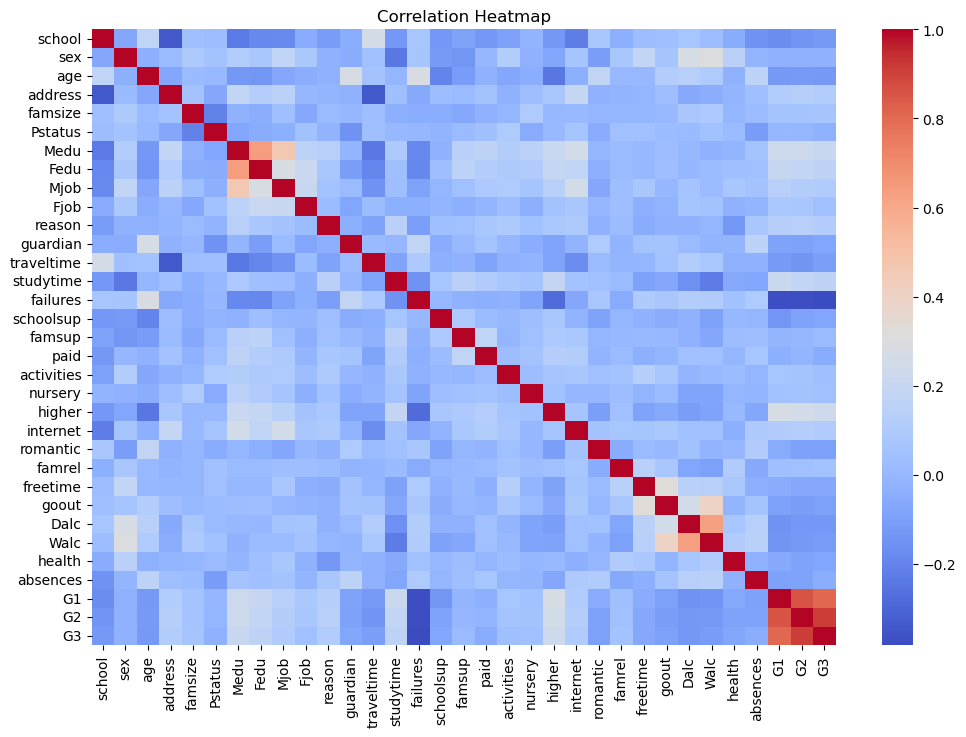

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


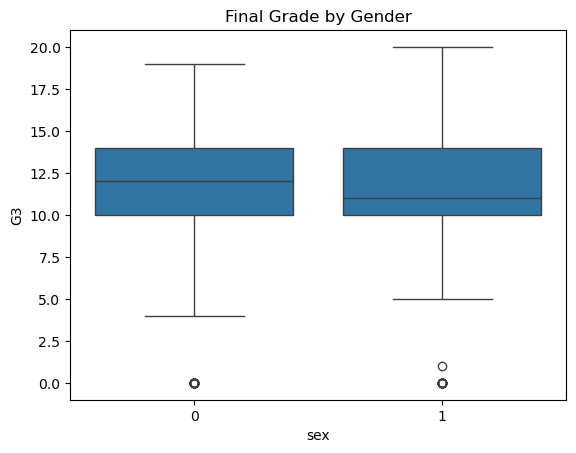

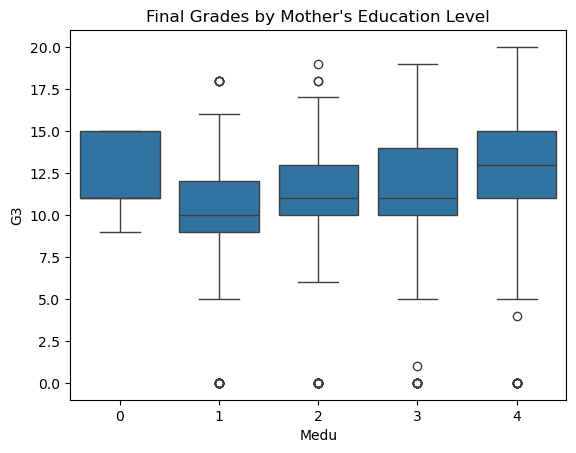

In [15]:
# Grades by gender
sns.boxplot(x='sex', y='G3', data=data)
plt.title("Final Grade by Gender")
plt.show()

# Grades by parental education level
sns.boxplot(x='Medu', y='G3', data=data)
plt.title("Final Grades by Mother's Education Level")
plt.show()


In [17]:
# Create binary target: 1 = pass (G3 >= 10), 0 = fail (G3 < 10)
data['pass_fail'] = data['G3'].apply(lambda x: 1 if x >= 10 else 0)


In [19]:
X = data.drop(columns=['G3', 'pass_fail'])
y_class = data['pass_fail']  # For classification
y_reg = data['G3']           # For regression


In [21]:
# For classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.3, random_state=42)

# For regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.3, random_state=42)


In [23]:
# Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_cls, y_train_cls)
y_pred_cls = clf.predict(X_test_cls)


In [25]:
# Random Forest Regressor
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)
y_pred_reg = reg.predict(X_test_reg)


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.67      0.77        79
           1       0.90      0.97      0.93       235

    accuracy                           0.90       314
   macro avg       0.90      0.82      0.85       314
weighted avg       0.90      0.90      0.89       314

Accuracy: 0.8980891719745223


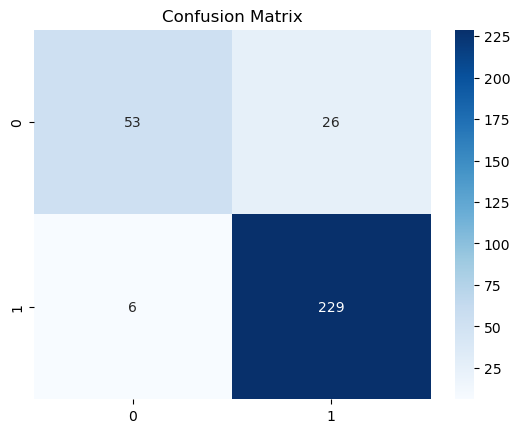

In [27]:
# Classification evaluation
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls)}")

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_cls, y_pred_cls), annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.show()


Regression Metrics:
R² Score: 0.808580417525745
Mean Squared Error: 2.839974203821656


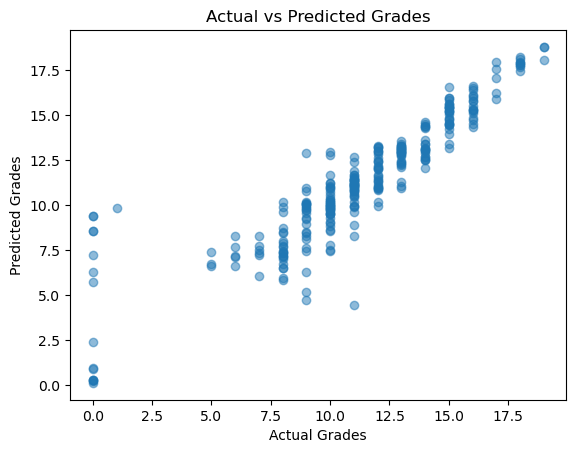

In [29]:
# Regression evaluation
print("Regression Metrics:")
print(f"R² Score: {r2_score(y_test_reg, y_pred_reg)}")
print(f"Mean Squared Error: {mean_squared_error(y_test_reg, y_pred_reg)}")

# Actual vs Predicted Plot
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.title("Actual vs Predicted Grades")
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.show()


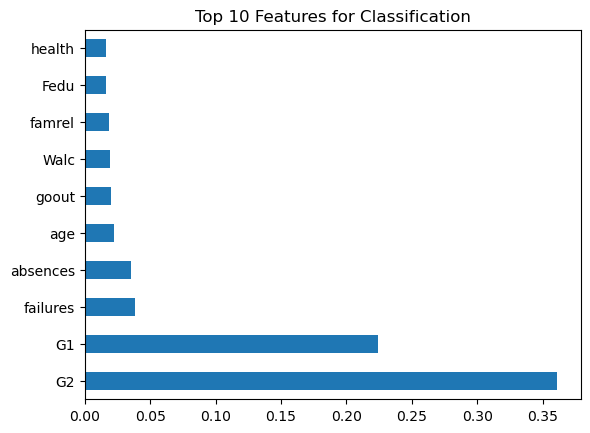

In [31]:
# Feature importance for classification
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Features for Classification")
plt.show()


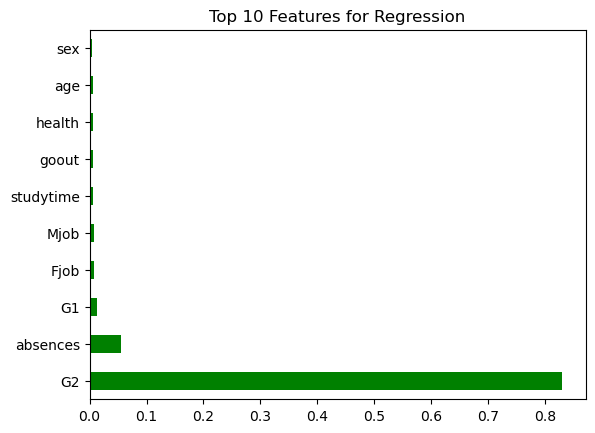

In [33]:
# Feature importance for regression
importances_reg = pd.Series(reg.feature_importances_, index=X.columns)
importances_reg.nlargest(10).plot(kind='barh', color='green')
plt.title("Top 10 Features for Regression")
plt.show()


## Decision Tree Regressor: 

In [39]:
# Load the datasets
file_path_mat = 'Cleaned_student-mat2.xlsx'
file_path_por = 'Cleaned_student-por2.xlsx'


In [41]:
student_mat = pd.read_excel(file_path_mat)
student_por = pd.read_excel(file_path_por)

# Combine datasets
combined_data = pd.concat([student_mat, student_por])

# Define features and target variable
X = combined_data.drop(columns=['G3'])  # exclude final grade G3
y = combined_data['G3']  # Target variable

# One-hot encode categorical variables (One-hot encoding is a process used to convert categorical (non-numeric) 
#(data into a numerical format that machine learning models can understand.)
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# Decision Tree Regressor
decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train, y_train)

# Predictions and evaluation
y_pred = decision_tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")

Mean Squared Error: 5.165605095541402


In [43]:
# Visualize Feature Importances
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances and sort them
feature_importances = decision_tree.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_features = [X_encoded.columns[i] for i in sorted_idx]

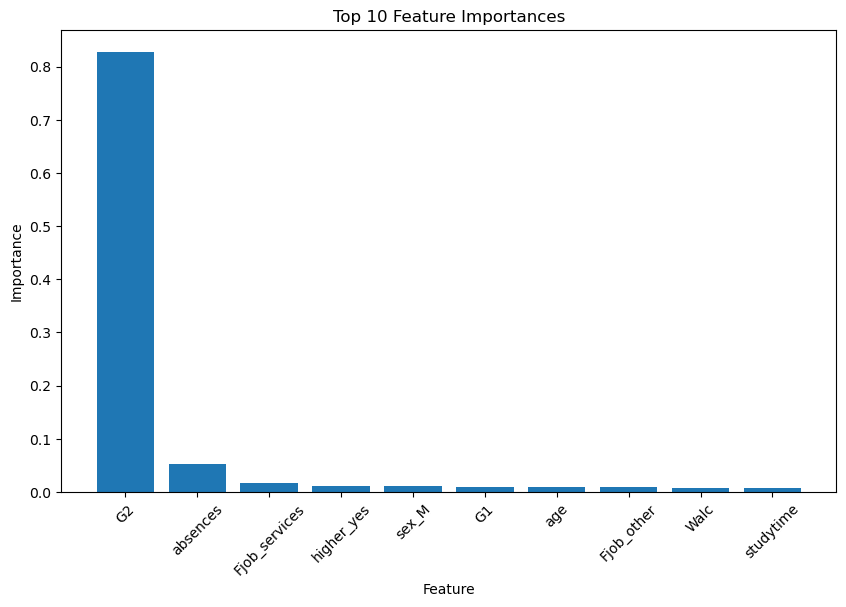

In [45]:
# Ploting the feature importances
plt.figure(figsize=(10, 6))
plt.bar(sorted_features[:10], feature_importances[sorted_idx][:10])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances")
plt.xticks(rotation=45)
plt.show()

## interpretation: This graph shows which factors are most important for predicting the final grade (`G3`). The second period grade (`G2`) is the most important factor by far. Other factors like absences and parents' jobs matter a little, but not nearly as much. This means how well a student did in the second period strongly affects their final grade.

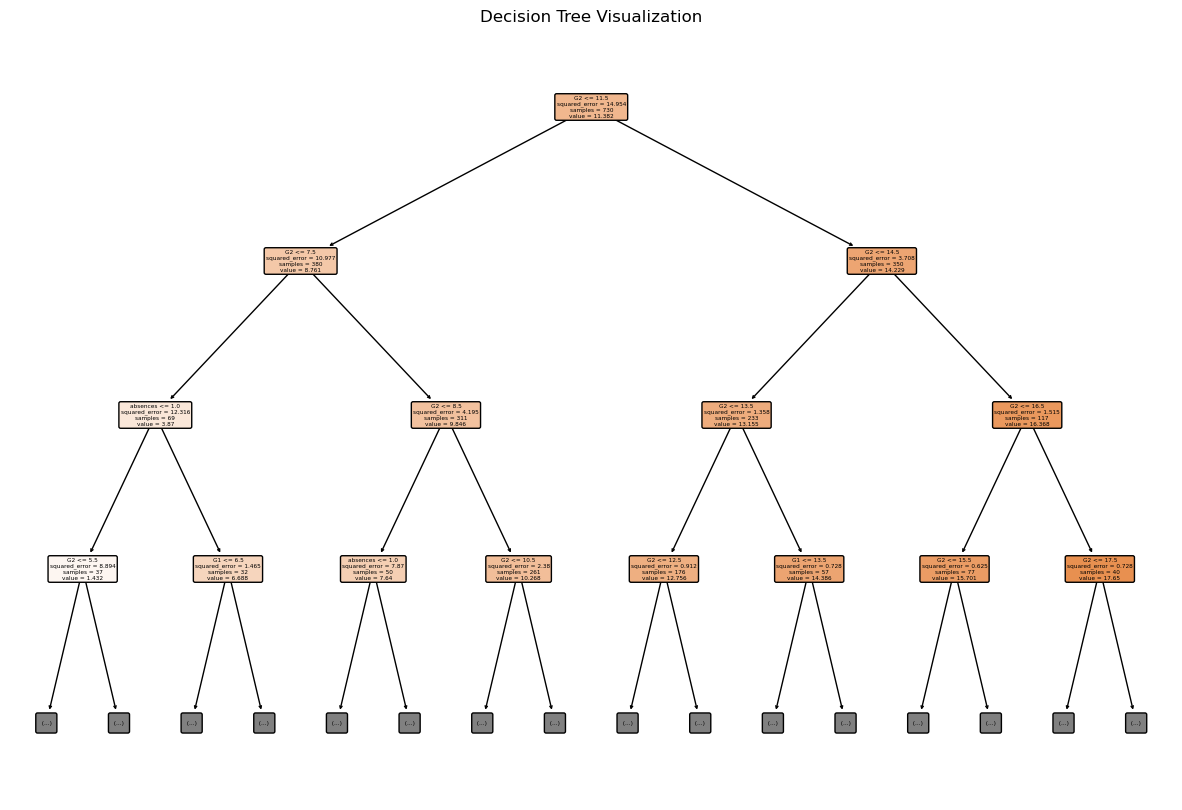

In [53]:
# the decision tree
plt.figure(figsize=(15, 10))
plot_tree(
    decision_tree,
    feature_names=X_encoded.columns,
    filled=True,
    rounded=True,
    max_depth=3  
)
plt.title("Decision Tree Visualization")
plt.show()


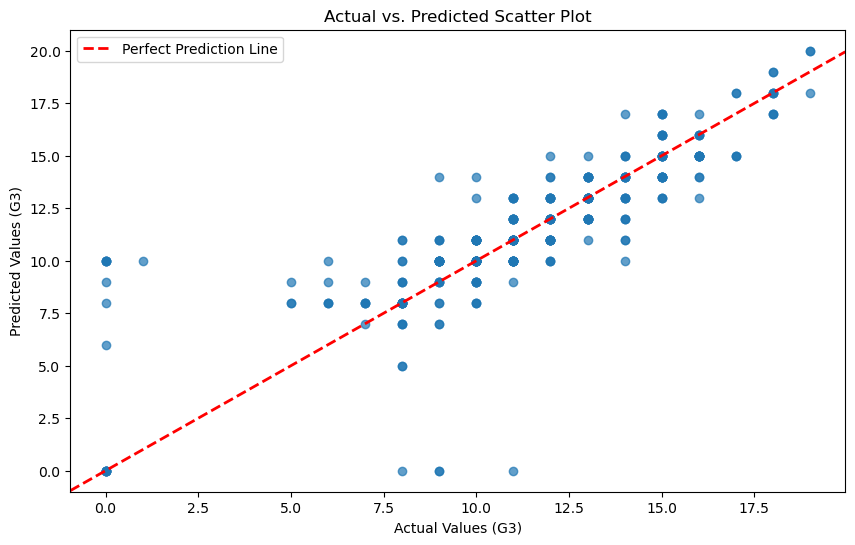

In [55]:
# Create a scatter plot for Actual vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Values (G3)")
plt.ylabel("Predicted Values (G3)")
plt.title("Actual vs. Predicted Scatter Plot")
plt.axline((0, 0), slope=1, color="red", linestyle="--", linewidth=2, label="Perfect Prediction Line")  
plt.legend()
plt.show()


This chart compares the actual grades (G3) with the grades predicted by the model. 

- The red dashed line shows perfect predictions. If all points were on this line, the model's predictions would match the actual grades exactly.
- Most points are close to the line, meaning the model predicts grades quite well for most students.
- Some points are far from the line, showing where the model's predictions are less accurate.
- Overall, the chart shows a positive trend, meaning the model predicts higher grades for students with higher actual grades, which is a good sign. However, there is still room to improve accuracy.